# 🧹 Preprocessing, Cleaning & EDA
Load the raw scraped data, clean it, engineer features, run EDA, and visualize.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📥 Load Raw Data

In [4]:
df_raw = pd.read_csv("travel_dataset_final.csv")

print("\n" + "=" * 60)
print("DATA QUALITY HANDLING & CLEANING PIPELINE")
print("=" * 60)

print("\n📋 RAW DATA STATISTICS:")
print(f"   Total records: {len(df_raw)}")
print(f"   Columns: {list(df_raw.columns)}")
print(f"   Data types:\n{df_raw.dtypes}")


DATA QUALITY HANDLING & CLEANING PIPELINE

📋 RAW DATA STATISTICS:
   Total records: 127
   Columns: ['origin', 'destination', 'date', 'flight_name', 'airplane_name', 'from_time', 'to_time', 'stops', 'duration', 'cabin', 'price']
   Data types:
origin               str
destination          str
date                 str
flight_name          str
airplane_name    float64
from_time            str
to_time              str
stops                str
duration             str
cabin                str
price            float64
dtype: object


## 🔍 Step 1 — Identify Quality Issues

In [5]:
print("\n🔍 STEP 1: Identify Quality Issues")
print("-" * 60)

duplicates = df_raw.duplicated().sum()
print(f"   • Duplicate rows: {duplicates}")

missing = df_raw.isnull().sum()
print(f"   • Missing values:\n{missing}")

invalid_prices = (df_raw['price'] <= 0).sum()
print(f"   • Invalid prices (≤ 0): {invalid_prices}")

Q1 = df_raw['price'].quantile(0.25)
Q3 = df_raw['price'].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df_raw['price'] < Q1 - 1.5*IQR) | (df_raw['price'] > Q3 + 1.5*IQR)).sum()
print(f"   • Statistical outliers (IQR method): {outliers}")


🔍 STEP 1: Identify Quality Issues
------------------------------------------------------------
   • Duplicate rows: 0
   • Missing values:
origin             0
destination        0
date               0
flight_name        0
airplane_name    127
from_time          0
to_time            0
stops              0
duration           0
cabin              0
price              0
dtype: int64
   • Invalid prices (≤ 0): 0
   • Statistical outliers (IQR method): 17


## 🔧 Step 2 — Handle Missing Data

In [6]:
print("\n🔧 STEP 2: Handle Missing Data")
print("-" * 60)

df_clean = df_raw.copy()
missing_before = df_clean.isnull().any(axis=1).sum()
df_clean = df_clean.dropna(subset=['flight_name'])
print(f"   • Rows dropped (missing critical fields): {missing_before - df_clean.isnull().any(axis=1).sum()}")
print(f"   • Records remaining: {len(df_clean)}")


🔧 STEP 2: Handle Missing Data
------------------------------------------------------------
   • Rows dropped (missing critical fields): 0
   • Records remaining: 127


## 🔧 Step 3 — Remove Duplicates

In [7]:
print("\n🔧 STEP 3: Remove Duplicates")
print("-" * 60)

dup_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"   • Removed {dup_before - len(df_clean)} duplicate records")
print(f"   • Records remaining: {len(df_clean)}")


🔧 STEP 3: Remove Duplicates
------------------------------------------------------------
   • Removed 0 duplicate records
   • Records remaining: 127


## 🔧 Step 4 — Remove Invalid Prices

In [8]:
print("\n🔧 STEP 4: Remove Invalid Prices")
print("-" * 60)

invalid_before = len(df_clean)
df_clean = df_clean[df_clean['price'] > 0]
print(f"   • Removed {invalid_before - len(df_clean)} records with prices ≤ $0")
print(f"   • Records remaining: {len(df_clean)}")


🔧 STEP 4: Remove Invalid Prices
------------------------------------------------------------
   • Removed 0 records with prices ≤ $0
   • Records remaining: 127


## 🔧 Step 5 — Flag Outliers (IQR Method)

In [9]:
print("\n🔧 STEP 5: Handle Outliers (Keep but Flag)")
print("-" * 60)

Q1 = df_clean['price'].quantile(0.25)
Q3 = df_clean['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean['is_outlier'] = (df_clean['price'] < lower_bound) | (df_clean['price'] > upper_bound)
outlier_count = df_clean['is_outlier'].sum()
print(f"   • Identified {outlier_count} outliers")
print(f"   • Normal price range: ${lower_bound:.2f} – ${upper_bound:.2f}")
print(f"   • Outliers flagged but retained")


🔧 STEP 5: Handle Outliers (Keep but Flag)
------------------------------------------------------------
   • Identified 17 outliers
   • Normal price range: $-209.50 – $1014.50
   • Outliers flagged but retained


## ✨ Step 6 — Feature Engineering

In [10]:
print("\n✨ STEP 6: Create Derived Features")
print("-" * 60)

df_clean['tax']        = df_clean['price'] * 0.15
df_clean['total_cost'] = df_clean['price'] + df_clean['tax']

df_clean['budget_level'] = df_clean['total_cost'].apply(
    lambda x: "Low (< $200)"     if x < 200
    else      "Medium ($200-500)" if x < 500
    else      "High (> $500)"
)

df_clean['affordability_score'] = 1000 / df_clean['total_cost']
df_clean['travel_date']         = pd.to_datetime(df_clean['date'])
df_clean['day_of_week']         = df_clean['travel_date'].dt.day_name()

print("   • Added: tax (15%), total_cost, budget_level, affordability_score, day_of_week")


✨ STEP 6: Create Derived Features
------------------------------------------------------------
   • Added: tax (15%), total_cost, budget_level, affordability_score, day_of_week


## 🗑️ Step 7 — Finalize Columns

In [11]:
print("\n🗑️ STEP 7: Finalize Column Selection")
print("-" * 60)

df_clean = df_clean.drop(columns=['travel_date'])

final_columns = [
    'origin', 'destination', 'date', 'day_of_week',
    'flight_name', 'airplane_name', 'from_time', 'to_time',
    'stops', 'duration', 'cabin',
    'price', 'tax', 'total_cost',
    'budget_level', 'affordability_score', 'is_outlier'
]
df_clean = df_clean[[col for col in final_columns if col in df_clean.columns]]

print(f"   • Final columns: {list(df_clean.columns)}")
print(f"\n📊 DATA CLEANING SUMMARY")
print(f"   Raw records:     {len(df_raw)}")
print(f"   Final records:   {len(df_clean)}")
print(f"   Removed:         {len(df_raw) - len(df_clean)}")
print(f"\n{df_clean.head()}")


🗑️ STEP 7: Finalize Column Selection
------------------------------------------------------------
   • Final columns: ['origin', 'destination', 'date', 'day_of_week', 'flight_name', 'airplane_name', 'from_time', 'to_time', 'stops', 'duration', 'cabin', 'price', 'tax', 'total_cost', 'budget_level', 'affordability_score', 'is_outlier']

📊 DATA CLEANING SUMMARY
   Raw records:     127
   Final records:   127
   Removed:         0

  origin destination        date day_of_week flight_name  airplane_name  \
0    CAI         LXR  2026-05-05     Tuesday   Air Cairo            NaN   
1    CAI         LXR  2026-05-05     Tuesday    Egyptair            NaN   
2    CAI         LXR  2026-05-05     Tuesday    Egyptair            NaN   
3    LXR         CAI  2026-05-05     Tuesday    Egyptair            NaN   
4    CAI         SSH  2026-05-05     Tuesday   Air Cairo            NaN   

  from_time   to_time    stops duration          cabin  price    tax  \
0   5:15 pm   6:55 pm  nonstop   1h 40m  Eco

## 📊 EDA — Descriptive Statistics

In [12]:
print("\n" + "=" * 60)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 60)

print("\n📊 DESCRIPTIVE STATISTICS")
print("-" * 60)
print(df_clean[['price', 'total_cost', 'affordability_score']].describe().round(2))


EXPLORATORY DATA ANALYSIS (EDA)

📊 DESCRIPTIVE STATISTICS
------------------------------------------------------------
         price  total_cost  affordability_score
count   127.00      127.00               127.00
mean    553.19      636.17                 2.88
std     520.15      598.17                 2.24
min      84.00       96.60                 0.31
25%     249.50      286.92                 1.57
50%     406.00      466.90                 2.14
75%     555.50      638.83                 3.49
max    2762.00     3176.30                10.35


## 🎯 Price Analysis by Destination & Route

In [13]:
dest_analysis = df_clean.groupby('destination').agg({
    'price':               ['count', 'mean', 'std', 'min', 'max'],
    'total_cost':          'mean',
    'affordability_score': 'mean'
}).round(2)
print(dest_analysis)

cheapest_dest        = df_clean.groupby('destination')['price'].mean().idxmin()
cheapest_price       = df_clean.groupby('destination')['price'].mean().min()
most_expensive_dest  = df_clean.groupby('destination')['price'].mean().idxmax()
most_expensive_price = df_clean.groupby('destination')['price'].mean().max()

print(f"\n   🏆 Cheapest:     {cheapest_dest} (${cheapest_price:.2f} avg)")
print(f"   💰 Most Expensive: {most_expensive_dest} (${most_expensive_price:.2f} avg)")
print(f"   📈 Difference:     ${most_expensive_price - cheapest_price:.2f}")

print("\n✈️  ROUTE ANALYSIS")
route_analysis = df_clean.groupby(['origin', 'destination']).agg({'price': ['count', 'mean']}).round(2)
print(route_analysis)

            price                                total_cost  \
            count    mean     std    min     max       mean   
destination                                                   
ASW             2  233.50    6.36  229.0   238.0     268.52   
CAI            63  411.89  263.00   86.0  1137.0     473.67   
HRG             4  131.50   37.25  104.0   186.0     151.22   
LXR             3  189.00   65.11  114.0   231.0     217.35   
MIL            50  842.96  671.17  213.0  2762.0     969.40   
SSH             5  119.60   38.84   84.0   186.0     137.54   

            affordability_score  
                           mean  
destination                      
ASW                        3.73  
CAI                        3.12  
HRG                        6.95  
LXR                        5.10  
MIL                        1.58  
SSH                        7.78  

   🏆 Cheapest:     SSH ($119.60 avg)
   💰 Most Expensive: MIL ($842.96 avg)
   📈 Difference:     $723.36

✈️  ROUTE ANALYSIS


## 💳 Budget Distribution & Affordability

In [14]:
budget_dist = df_clean['budget_level'].value_counts()
print("\n💳 BUDGET LEVEL DISTRIBUTION")
print(budget_dist)
print((budget_dist / len(df_clean) * 100).round(1))

print("\n🎯 TOP 10 MOST AFFORDABLE TRIPS")
top_affordable = df_clean.nlargest(10, 'affordability_score')[
    ['origin', 'destination', 'date', 'flight_name', 'price', 'total_cost', 'affordability_score', 'budget_level']
]
print(top_affordable.to_string())

print("\n🎯 TOP 10 MOST EXPENSIVE TRIPS")
top_expensive = df_clean.nlargest(10, 'price')[
    ['origin', 'destination', 'date', 'flight_name', 'price', 'total_cost', 'budget_level']
]
print(top_expensive.to_string())


💳 BUDGET LEVEL DISTRIBUTION
budget_level
High (> $500)        59
Medium ($200-500)    52
Low (< $200)         16
Name: count, dtype: int64
budget_level
High (> $500)        46.5
Medium ($200-500)    40.9
Low (< $200)         12.6
Name: count, dtype: float64

🎯 TOP 10 MOST AFFORDABLE TRIPS
    origin destination        date flight_name  price  total_cost  affordability_score  budget_level
4      CAI         SSH  2026-05-05   Air Cairo   84.0        96.6            10.351967  Low (< $200)
9      SSH         CAI  2026-05-05   Air Cairo   86.0        98.9            10.111223  Low (< $200)
5      CAI         SSH  2026-05-05   Air Cairo  104.0       119.6             8.361204  Low (< $200)
10     SSH         CAI  2026-05-05   Air Cairo  104.0       119.6             8.361204  Low (< $200)
119    CAI         HRG  2026-05-05   Air Cairo  104.0       119.6             8.361204  Low (< $200)
123    HRG         CAI  2026-05-05   Air Cairo  106.0       121.9             8.203445  Low (< $200)
7 

## 📊 Correlations

In [15]:
numeric_cols = df_clean[['price', 'tax', 'total_cost', 'affordability_score']].corr()
print(numeric_cols.round(3))

                     price    tax  total_cost  affordability_score
price                1.000  1.000       1.000               -0.623
tax                  1.000  1.000       1.000               -0.623
total_cost           1.000  1.000       1.000               -0.623
affordability_score -0.623 -0.623      -0.623                1.000


## 📈 Visualizations


✓ Saved: flight_analysis_dashboard.png


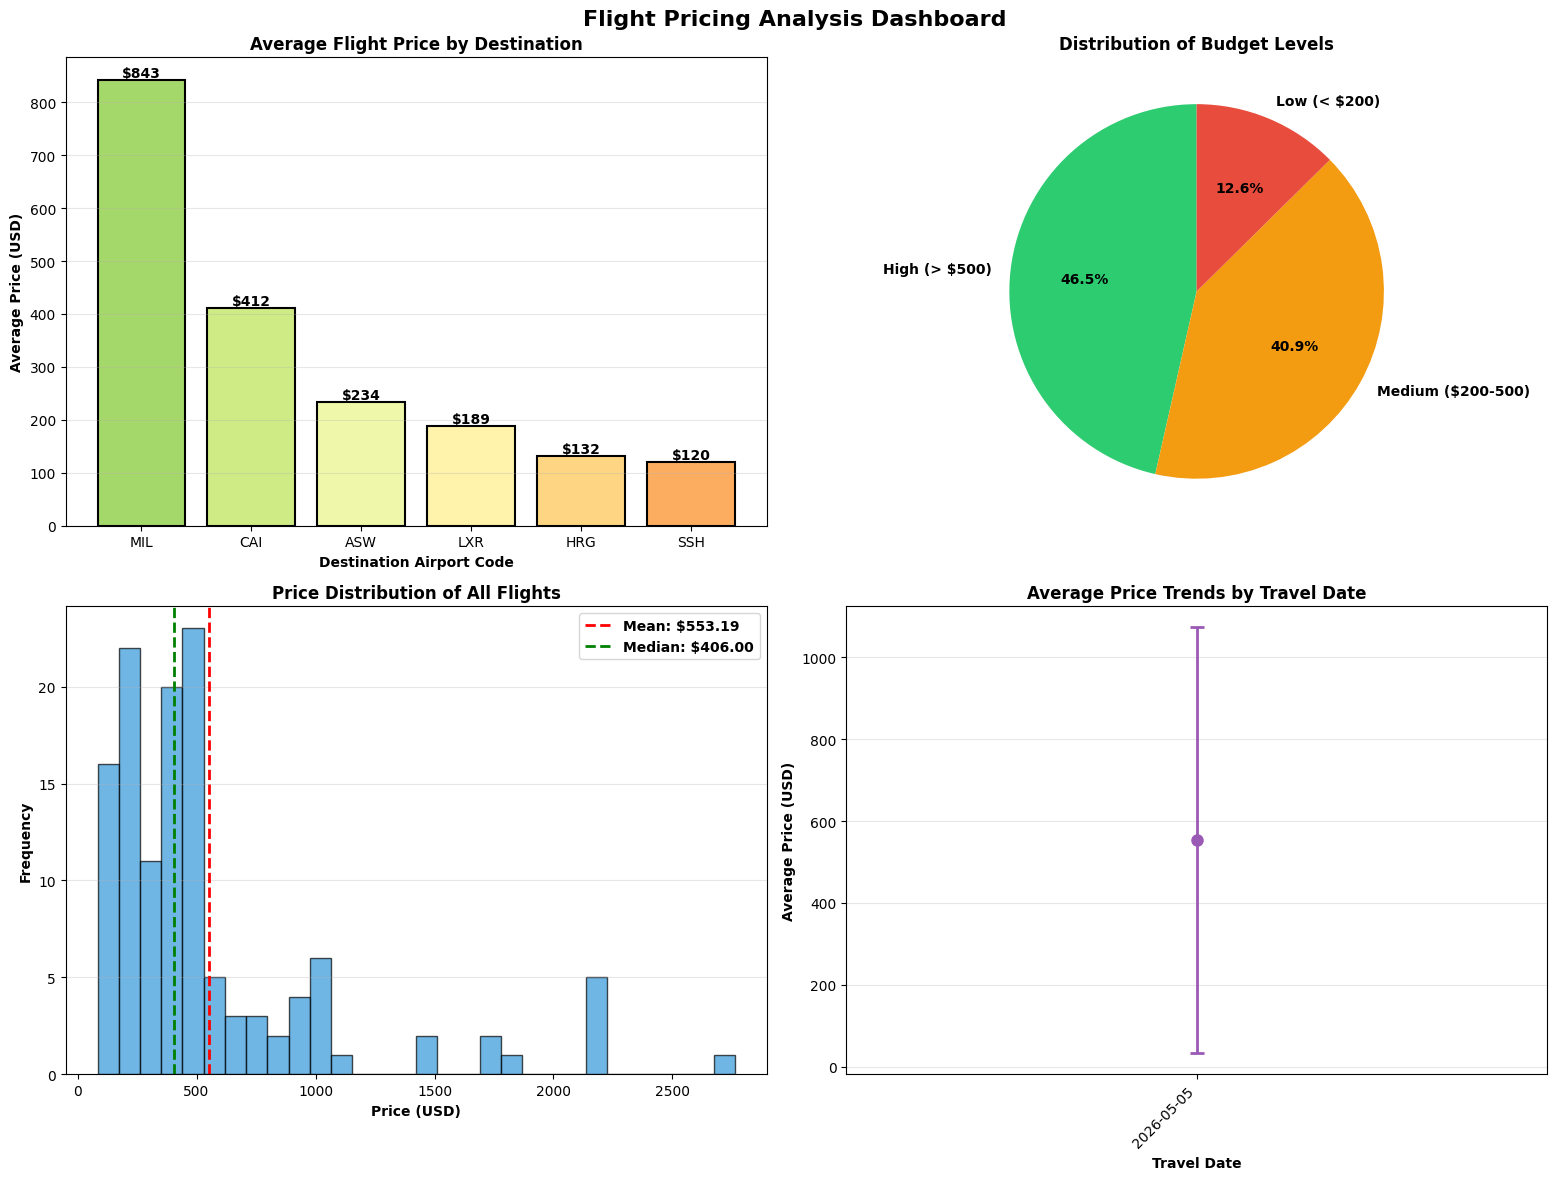

In [16]:
plt.style.use('default')
sns.set_palette("husl")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Flight Pricing Analysis Dashboard', fontsize=16, fontweight='bold')

# --- Plot 1: Average Price by Destination ---
ax1 = axes[0, 0]
dest_prices = df_clean.groupby('destination')['price'].mean().sort_values(ascending=False)
if len(dest_prices) > 0:
    colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.7, len(dest_prices)))
    bars1  = ax1.bar(dest_prices.index, dest_prices.values, color=colors, edgecolor='black', linewidth=1.5)
    ax1.set_title('Average Flight Price by Destination', fontweight='bold', fontsize=12)
    ax1.set_xlabel('Destination Airport Code', fontweight='bold')
    ax1.set_ylabel('Average Price (USD)', fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    for bar in bars1:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., h, f'${h:.0f}', ha='center', va='bottom', fontweight='bold')

# --- Plot 2: Budget Level Pie Chart ---
ax2 = axes[0, 1]
budget_data = df_clean['budget_level'].value_counts()
if len(budget_data) > 0:
    colors_budget = ['#2ecc71', '#f39c12', '#e74c3c'][:len(budget_data)]
    ax2.pie(budget_data.values, labels=budget_data.index, autopct='%1.1f%%',
            colors=colors_budget, startangle=90, textprops={'fontweight': 'bold'})
    ax2.set_title('Distribution of Budget Levels', fontweight='bold', fontsize=12)

# --- Plot 3: Price Histogram ---
ax3 = axes[1, 0]
if len(df_clean) > 1:
    ax3.hist(df_clean['price'], bins=min(30, len(df_clean)), color='#3498db', edgecolor='black', alpha=0.7)
    ax3.axvline(df_clean['price'].mean(),   color='red',   linestyle='--', linewidth=2, label=f'Mean: ${df_clean["price"].mean():.2f}')
    ax3.axvline(df_clean['price'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: ${df_clean["price"].median():.2f}')
    ax3.set_title('Price Distribution of All Flights', fontweight='bold', fontsize=12)
    ax3.set_xlabel('Price (USD)', fontweight='bold')
    ax3.set_ylabel('Frequency',   fontweight='bold')
    ax3.legend(prop={'weight': 'bold'})
    ax3.grid(axis='y', alpha=0.3)

# --- Plot 4: Price Trend by Date ---
ax4 = axes[1, 1]
date_prices = df_clean.groupby('date')['price'].agg(['mean', 'std']).fillna(0)
if len(date_prices) > 0:
    ax4.errorbar(range(len(date_prices)), date_prices['mean'], yerr=date_prices['std'],
                 fmt='o-', linewidth=2, markersize=8, capsize=5, capthick=2, color='#9b59b6')
    ax4.set_xticks(range(len(date_prices)))
    ax4.set_xticklabels(date_prices.index, rotation=45, ha='right')
    ax4.set_title('Average Price Trends by Travel Date', fontweight='bold', fontsize=12)
    ax4.set_xlabel('Travel Date',       fontweight='bold')
    ax4.set_ylabel('Average Price (USD)', fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('flight_analysis_dashboard.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: flight_analysis_dashboard.png")
plt.show()

## 💡 Key Insights

In [17]:
date_analysis = df_clean.groupby('date').agg({'price': ['count', 'mean', 'std'], 'total_cost': 'mean'}).round(2)

print(f"""
1. DESTINATION PRICING:
   • Cheapest:      {cheapest_dest} (${cheapest_price:.2f} avg)
   • Most Expensive:{most_expensive_dest} (${most_expensive_price:.2f} avg)
   • Difference:    ${most_expensive_price - cheapest_price:.2f}

2. BUDGET DISTRIBUTION:
   • Low (<$200):      {(budget_dist.get('Low (< $200)',     0) / max(len(df_clean),1) * 100):.1f}%
   • Medium ($200-500):{(budget_dist.get('Medium ($200-500)',0) / max(len(df_clean),1) * 100):.1f}%
   • High (>$500):     {(budget_dist.get('High (> $500)',    0) / max(len(df_clean),1) * 100):.1f}%

3. OUTLIERS:
   • Count: {df_clean['is_outlier'].sum()} ({(df_clean['is_outlier'].sum() / max(len(df_clean),1) * 100):.1f}%)
   • Normal range: ${lower_bound:.2f} – ${upper_bound:.2f}

4. AFFORDABILITY:
   • Avg score: {df_clean['affordability_score'].mean():.2f}
   • Best value destinations: {list(df_clean.nlargest(3,'affordability_score')['destination'].unique()[:3])}

5. DATA QUALITY:
   • Removed {len(df_raw) - len(df_clean)} records — retained {len(df_clean)} clean records
""")


1. DESTINATION PRICING:
   • Cheapest:      SSH ($119.60 avg)
   • Most Expensive:MIL ($842.96 avg)
   • Difference:    $723.36

2. BUDGET DISTRIBUTION:
   • Low (<$200):      12.6%
   • Medium ($200-500):40.9%
   • High (>$500):     46.5%

3. OUTLIERS:
   • Count: 17 (13.4%)
   • Normal range: $-209.50 – $1014.50

4. AFFORDABILITY:
   • Avg score: 2.88
   • Best value destinations: ['SSH', 'CAI']

5. DATA QUALITY:
   • Removed 0 records — retained 127 clean records



## 💾 Save Cleaned Dataset

In [19]:
df_clean.to_csv("travel_dataset_final2.csv",   index=False)
df_clean.to_json("travel_dataset_final.json",  orient="records", indent=2)
df_clean.to_excel("travel_dataset_final.xlsx", index=False)

print(f"\n✅ Saved {len(df_clean)} cleaned records to:")
print("   • travel_dataset_final.csv")
print("   • travel_dataset_final.json")
print("   • travel_dataset_final.xlsx")


✅ Saved 127 cleaned records to:
   • travel_dataset_final.csv
   • travel_dataset_final.json
   • travel_dataset_final.xlsx
